In [1]:
from google.colab import drive

# Kết nối Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install mtcnn
!pip install keras-facenet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=5d4b90b285fb48231882811a67ef6e264d4b7298d156733af3b49e22a3d82535
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras-facenet


In [3]:
import cv2 as cv
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [11]:
img_test = cv.imread("/content/drive/MyDrive/FaceRecognition1MinhTao/Face_dataset/Tran Duc Luong DHKL16A2HN/2.jpg")


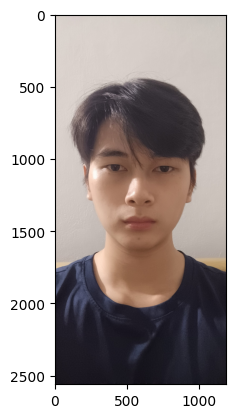

In [12]:
img_test = cv.cvtColor(img_test,cv.COLOR_BGR2RGB)
plt.imshow(img_test)

In [13]:
from mtcnn.mtcnn import MTCNN

detector = MTCNN()
results = detector.detect_faces(img_test)


In [14]:
results

[{'box': [201, 750, 752, 917],
  'confidence': np.float64(0.9999673366546631),
  'keypoints': {'nose': [np.int64(581), np.int64(1261)],
   'mouth_right': [np.int64(711), np.int64(1449)],
   'right_eye': [np.int64(755), np.int64(1072)],
   'left_eye': [np.int64(420), np.int64(1063)],
   'mouth_left': [np.int64(442), np.int64(1448)]}}]

In [15]:
x,y,w,h = results[0]['box']


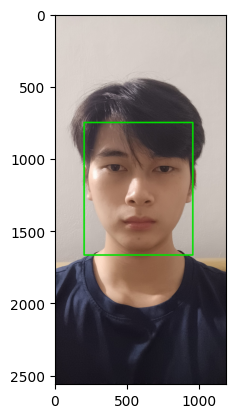

In [16]:
img_test = cv.rectangle(img_test,(x,y),(x+w,y+h),(0,225,0),10)
plt.imshow(img_test)

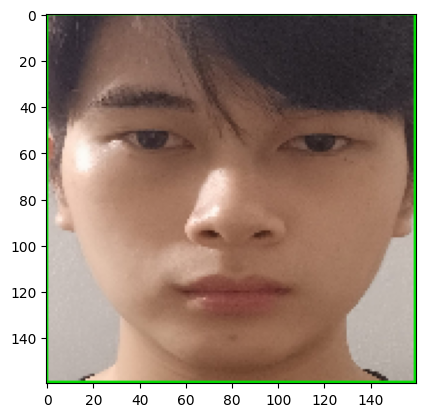

In [17]:
my_face = img_test[y:y+h,x:x+w]
my_face = cv.resize(my_face,(160,160))
plt.imshow(my_face)

In [18]:
class Faceloading:
  def __init__(self,directory):
    self.directory = directory
    self.targetsize = (160,160)
    self.X=[]
    self.Y=[]
    self.detector = MTCNN()

  def extract_face(self,filename,required_size=(160,160)):
    image = cv.imread(filename)
    image = cv.cvtColor(image,cv.COLOR_BGR2RGB)
    x,y,w,h = self.detector.detect_faces(image)[0]['box']
    x,y  = abs(x),abs(y)
    face = image[y:y+h,x:x+w]
    face_arr = cv.resize(face,required_size)
    return face_arr

  def load_faces(self,dir):
    FACES=[]
    for im_name in os.listdir(dir):
      try:
        path = dir + im_name
        single_face = self.extract_face(path)
        FACES.append(single_face)
      except Exception as e:
        pass
    return FACES

  def load_classes(self):
    for subdir in os.listdir(self.directory):
      path = self.directory +'/' + subdir + '/'
      FACES = self.load_faces(path)
      labels = [subdir for _ in range(len(FACES))]
      print('loaded %d examples for class: %s' % (len(FACES),subdir))
      self.X.extend(FACES)
      self.Y.extend(labels)

    return np.asarray(self.X),np.asarray(self.Y)

  def plot_img(self):
    plt.figure(figsize=(10,16))
    for num,image in enumerate(self.X):
      ncols = 3
      nrows = len(self.Y)//ncols + 1
      plt.subplot(nrows,ncols,num+1)
      plt.imshow(image)
      plt.axis('off')

In [19]:
faceloading = Faceloading("/content/drive/MyDrive/FaceRecognition1MinhTao/Face_dataset")
X, Y = faceloading.load_classes()

loaded 6 examples for class: Vu Tien Dung DHKL17A1HN
loaded 10 examples for class: Trinh Ngoc Toan DHKL18A2HN
loaded 5 examples for class: Trinh Phuong Thuy DHKL18A1HN
loaded 6 examples for class: Pham Le Nhat Minh DHKL17A1HN
loaded 6 examples for class: Nguyen Van Vinh DHKL17A1HN
loaded 4 examples for class: Tran Duc Luong DHKL16A2HN
loaded 6 examples for class: Nguyen Xuan Huy DHKL17A1HN
loaded 10 examples for class: Nguyen Thi Mai Chi DHKL17A2HN
loaded 6 examples for class: Tran Thi Thuy Linh DHKL18A2HN
loaded 5 examples for class: Nguyen Duc Dinh DHKL18A2HN
loaded 6 examples for class: Nguyen Ngoc Bac DHKL16A2HN
loaded 5 examples for class: Nguyen Minh Nguyet DHKL18A1HN
loaded 6 examples for class: Ho Thi Minh Hang DHKL16A2HN
loaded 6 examples for class: Nguyen Van Ha DHKL16A2HN
loaded 0 examples for class: Nguyễn Thành Văn DHKL18A1HN
loaded 9 examples for class: Do Manh Huan DHKL18A2HN
loaded 7 examples for class: Nguyen Thanh Van DHKL18A1HN
loaded 6 examples for class: Pham M

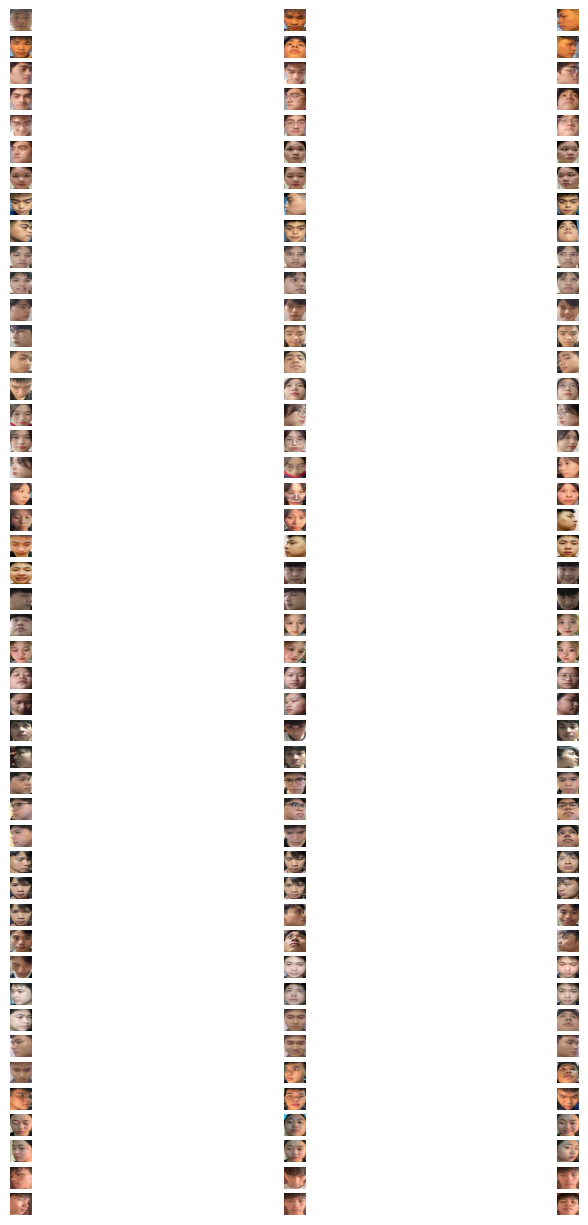

In [20]:
plt.figure(figsize=(10,16))
for num,image in enumerate(X):
  ncols = 3
  nrows = len(Y)//ncols + 1
  plt.subplot(nrows,ncols,num+1)
  plt.imshow(image)
  plt.axis('off')

In [21]:
from keras_facenet import FaceNet
embedder = FaceNet()

def get_embedding(face_img):
  face_img = face_img.astype('float32') #chuyen thanh 3d (160x160x3)
  face_img = np.expand_dims(face_img, axis = 0)
  yhat = embedder.embeddings(face_img)
  return yhat[0]


In [22]:
EMBEDDED_X = []

for img in X:
  EMBEDDED_X.append(get_embedding(img))

EMBEDDED_x  = np.asarray(EMBEDDED_X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [23]:
np.savez_compressed('faces_embedding_4classes.npz',EMBEDDED_X,Y)

In [24]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(Y)
Y = encoder.transform(Y)

Text(0, 0.5, '21')

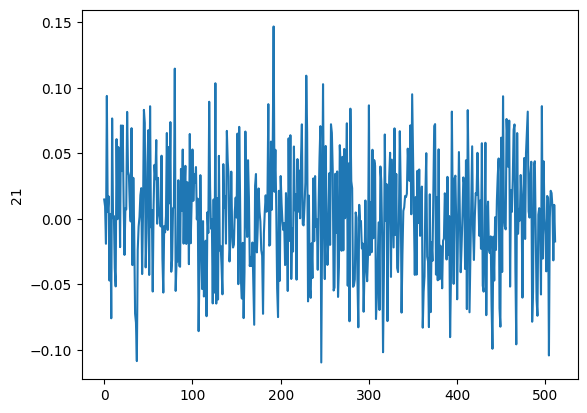

In [25]:
plt.plot(EMBEDDED_X[0])
plt.ylabel(Y[0])

In [26]:
Y

array([21, 21, 21, 21, 21, 21, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20,
       20, 20, 20, 20, 14, 14, 14, 14, 14, 14, 12, 12, 12, 12, 12, 12, 17,
       17, 17, 17, 13, 13, 13, 13, 13, 13, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 18, 18, 18, 18, 18, 18,  6,  6,  6,  6,  6,  8,  8,  8,  8,
        8,  8,  7,  7,  7,  7,  7,  4,  4,  4,  4,  4,  4, 11, 11, 11, 11,
       11, 11,  0,  0,  0,  0,  0,  0,  0,  0,  0,  9,  9,  9,  9,  9,  9,
        9, 15, 15, 15, 15, 15, 15,  5,  5,  5,  5,  5,  5,  1,  1,  1,  1,
        1,  1, 16, 16, 16, 16, 16,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3])

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(EMBEDDED_X,Y,test_size=0.2,random_state=42)

In [28]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Load dữ liệu embedding
data = np.load("faces_embedding_4classes.npz")
X = data['arr_0']             # embedding đầu ra từ FaceNet
y_raw = data['arr_1']         # nhãn tương ứng (tên người)

# Encode nhãn thành số
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(np.unique(y))

# MLP model
model = Sequential([
    Input(shape=(512,)),  # embedding từ FaceNet là vector 512 chiều
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Huấn luyện
history = model.fit(
    X, y,
    epochs=50,           # tăng số epoch tại đây nếu cần
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Lưu mô hình + encoder
model.save("mlp_face_classifier.h5")

import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.0567 - loss: 3.0837 - val_accuracy: 0.0000e+00 - val_loss: 3.1073
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2647 - loss: 3.0187 - val_accuracy: 0.0000e+00 - val_loss: 3.1332
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4378 - loss: 2.9599 - val_accuracy: 0.0000e+00 - val_loss: 3.1782
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5215 - loss: 2.8768 - val_accuracy: 0.0000e+00 - val_loss: 3.2407
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4956 - loss: 2.7840 - val_accuracy: 0.0000e+00 - val_loss: 3.3314
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5978 - loss: 2.6682 - val_accuracy: 0.0000e+00 - val_loss: 3.4578
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6273 - loss: 2.5485 - val_accuracy: 0.0000e+00 - val_loss: 3.6177
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6803 - loss: 2.3522 - val_accuracy

In [29]:
ypreds_train = model.predict(np.asarray(X_train))
ypreds_test = model.predict(np.asarray(X_test))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [30]:
from sklearn.metrics import accuracy_score

accuracy_score(Y_train, np.argmax(ypreds_train, axis=1))

0.8090909090909091

In [31]:
accuracy_score(Y_test, np.argmax(ypreds_test, axis=1))

0.9285714285714286

In [32]:
#test anh
t_im = cv.imread("/content/drive/MyDrive/Face_recognition/anh.png")
t_im = cv.cvtColor(t_im,cv.COLOR_BGR2RGB)
x,y,w,h = detector.detect_faces(t_im)[0]['box']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


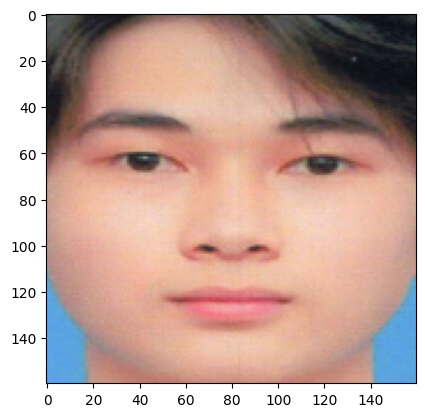

In [33]:
t_im = t_im[y:y+h,x:x+w]
t_im = cv.resize(t_im,(160,160))
test_im = get_embedding(t_im)
plt.imshow(t_im)

In [34]:
test_im_array = np.expand_dims(test_im, axis=0)
ypreds = model.predict(test_im_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [35]:
ypreds

array([[5.1820965e-04, 2.2071175e-05, 1.6585973e-05, 2.5703046e-05,
        3.8484260e-03, 5.1686913e-03, 1.1969294e-03, 1.7479956e-03,
        2.8238404e-03, 1.7156516e-03, 7.5653283e-04, 4.6765540e-02,
        7.8978584e-05, 1.5057005e-05, 5.7214876e-03, 1.9087309e-03,
        1.0148069e-05, 9.1521758e-01, 1.6370175e-03, 1.0085728e-02,
        2.1424588e-04, 5.0486549e-04]], dtype=float32)

In [36]:
encoder.inverse_transform(np.argmax(ypreds, axis=1))

array(['Tran Duc Luong DHKL16A2HN'], dtype='<U29')